In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [134]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    TextVectorization,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Dataset Shape: (45275, 2)

Missing Values:
 label    0
text     0
dtype: int64

Duplicates: 15721

Class Distribution:
 label
pos    22761
neg    22514
Name: count, dtype: int64


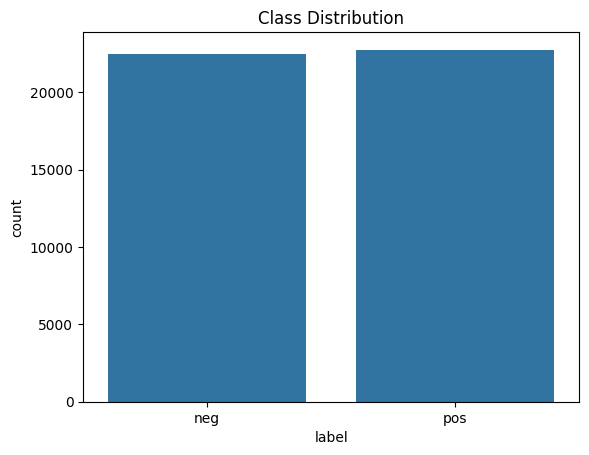

In [3]:
df = pd.read_csv("/kaggle/input/datasets/habibamuhammed1/arabic-toxic/arabic_tweets_dataset_combined.csv")

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nClass Distribution:\n", df["label"].value_counts())

sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.show()

In [8]:
print("=" * 70)

print("POSITIVE SAMPLES")

print("=" * 70)

positive_samples = df[df["label"] == "pos"]["text"].head(5)

for i, text in enumerate(positive_samples):

    print(f"\n[{i+1}]")

    print(text)

    print("-" * 70)


print("\n\n")


print("=" * 70)

print("NEGATIVE SAMPLES")

print("=" * 70)

negative_samples = df[df["label"] == "neg"]["text"].head(5)

for i, text in enumerate(negative_samples):

    print(f"\n[{i+1}]")

    print(text)

    print("-" * 70)

POSITIVE SAMPLES

[1]
لا ده صاحب مزاج هيخلص على العسل كلوو 😂
----------------------------------------------------------------------

[2]
صباح الخير والاجواء الزينه.. 🌸
----------------------------------------------------------------------

[3]
خارج النص | - فرحة مشجع عماني في نهائي كأس جلالة السلطان قابوس 😂
----------------------------------------------------------------------

[4]
لاترمون فساد وخراب بلدانكم على ال سعود انتم من عبثتم في وطنكم 😄
----------------------------------------------------------------------

[5]
✍🏻 ﻋﻨﺪﻣﺎ ﻳﺤﺒﺲ ﺍﻟﻀﻴﻖ ﺃﻧﻔﺎﺳﻚ ﺇﺭﺗﺸﻒ ﻣﺎﺀ ﺍﻹﻃﻤﺌﻨﺎﻥ ﻭﺃﻧﺖ ﺗﺮﺩﺩ : *ﺭﺑﻲ ﺇﺷﺮﺡ ﻟﻲ ﺻﺪﺭﻱ ، ﻭﻳﺴﺮ ﻟﻲ ﺃﻣﺮﻱ* .. * 🌹…
----------------------------------------------------------------------



NEGATIVE SAMPLES

[1]
اقول ياحظكم بالبرد وربي ودي عندكم 😭
----------------------------------------------------------------------

[2]
تخاف آ يطرا لينا بحال المونديال و نخسرو مع ناميبيا اللي كلشي حاكرها 😶
----------------------------------------------------------------------

[3]
ممكن كل شيء جايز 🤔 ال

In [9]:
label_mapping = {
    "neg": 0,
    "pos": 1
}

df["label_encoded"] = df["label"].map(label_mapping)

print(df[["label", "label_encoded"]].head())

  label  label_encoded
0   neg              0
1   neg              0
2   pos              1
3   pos              1
4   pos              1


In [26]:
def clean_text(text):
    
    text = str(text).lower()
    
    # Remove URLs and mentions
    text = re.sub(r'https?://\S+|www\.\S+|@\w+', '', text)
    
    # Remove diacritics
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652\u0640]', '', text)
    
    # Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    
    # Remove hashtags symbol but keep word
    text = text.replace("#", "")
    
    # Keep Arabic letters only
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    
    # Remove extra spaces
    return re.sub(r'\s+', ' ', text).strip()

In [27]:
df["clean_text"] = df["text"].apply(clean_text)

df = df[df["clean_text"] != ""]

In [28]:
arabic_diacritics = re.compile("""
    ّ    | # Tashdid
    َ    | # Fatha
    ً    | # Tanwin Fath
    ُ    | # Damma
    ٌ    | # Tanwin Damm
    ِ    | # Kasra
    ٍ    | # Tanwin Kasr
    ْ    | # Sukun
    ـ       # Tatweel
""", re.VERBOSE)

In [29]:
arabic_stopwords = set([
    "في", "من", "على", "الى", "إلى",
    "عن", "مع", "هذا", "هذه",
    "ذلك", "تلك", "هو", "هي",
    "كان", "كانت", "يكون",
    "انا", "انت", "انتي",
    "هم", "هن", "نحن",
    "او", "أو", "ثم",
    "قد", "لقد", "حتى",
    "كل", "كما"
])

In [32]:
comparison = df[
    ["text", "clean_text"]
].head(10)

comparison

,text,clean_text
0,اقول ياحظكم بالبرد وربي ودي عندكم 😭,اقول ياحظكم بالبرد وربي ودي عندكم
1,تخاف آ يطرا لينا بحال المونديال و نخسرو مع نام...,تخاف ا يطرا لينا بحال المونديال و نخسرو ناميبي...
2,لا ده صاحب مزاج هيخلص على العسل كلوو 😂,لا ده صاحب مزاج هيخلص علي العسل كلوو
3,صباح الخير والاجواء الزينه.. 🌸,صباح الخير والاجواء الزينه
4,خارج النص | - فرحة مشجع عماني في نهائي كأس جلا...,خارج النص فرحة مشجع عماني نهايي كاس جلالة السل...
5,ممكن كل شيء جايز 🤔 العلم عند الله ☝️,ممكن شيء جايز العلم عند الله
6,لاترمون فساد وخراب بلدانكم على ال سعود انتم من...,لاترمون فساد وخراب بلدانكم علي ال سعود انتم عب...
7,✍🏻 ﻋﻨﺪﻣﺎ ﻳﺤﺒﺲ ﺍﻟﻀﻴﻖ ﺃﻧﻔﺎﺳﻚ ﺇﺭﺗﺸﻒ ﻣﺎﺀ ﺍﻹﻃﻤﺌﻨﺎﻥ ...,،
8,اي احد بيسألني عن الوظيفة ، راح ارتكب فيه جريم...,اي احد بيسالني الوظيفة ، راح ارتكب فيه جريمة
9,بما اني نصراوي .. ضع رهان 😏,بما اني نصراوي ضع رهان


In [34]:
df = df[
    df["clean_text"].str.strip() != ""
]

df = df.reset_index(drop=True)

print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (45256, 4)


In [35]:
df["text_length"] = df["clean_text"].apply(
    lambda x: len(x.split())
)

print(
    df["text_length"].describe()
)

count    45256.000000
mean        11.178385
std         17.820647
min          1.000000
25%          5.000000
50%         10.000000
75%         16.000000
max       1308.000000
Name: text_length, dtype: float64


In [117]:
X = df["clean_text"].values

y = df["label_encoded"].values

In [118]:
df["label_encoded"] = pd.to_numeric(
    df["label_encoded"],
    errors="coerce"
)

df = df.dropna(subset=["label_encoded"])

df["label_encoded"] = df["label_encoded"].astype("float32")

In [95]:
X = df["clean_text"].astype(str).values
y = df["label_encoded"].astype("float32").values

print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

print("Unique y values:", np.unique(y))

X dtype: object
y dtype: float32
Unique y values: [0. 1.]


In [96]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Convert explicitly for TensorFlow
X_train = X_train.astype(str)
X_val = X_val.astype(str)
X_test = X_test.astype(str)

y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

print("\nFinal Data Types:")
print("X_train:", X_train.dtype)
print("y_train:", y_train.dtype)

print("\nUnique labels:")
print(np.unique(y_train))


Final Data Types:
X_train: <U7118
y_train: float32

Unique labels:
[0. 1.]


In [97]:
print("=" * 50)

print("TRAINING SET")

print("X_train:", X_train.shape)

print("y_train:", y_train.shape)


print("\nVALIDATION SET")

print("X_val:", X_val.shape)

print("y_val:", y_val.shape)


print("\nTEST SET")

print("X_test:", X_test.shape)

print("y_test:", y_test.shape)

print("=" * 50)

TRAINING SET
X_train: (31679,)
y_train: (31679,)

VALIDATION SET
X_val: (6788,)
y_val: (6788,)

TEST SET
X_test: (6789,)
y_test: (6789,)


In [99]:
X = df["clean_text"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (31679,)
Validation: (6788,)
Test: (6789,)


In [100]:
# Calculate number of words in each tweet
df["text_length"] = df["clean_text"].apply(
    lambda x: len(str(x).split())
)

# Show statistics
print(df["text_length"].describe())

# Calculate 95th percentile
MAX_LEN = int(
    np.percentile(df["text_length"], 95)
)

print("Recommended MAX_LEN:", MAX_LEN)

count    45256.000000
mean        11.178385
std         17.820647
min          1.000000
25%          5.000000
50%         10.000000
75%         16.000000
max       1308.000000
Name: text_length, dtype: float64
Recommended MAX_LEN: 21


In [122]:
X_final = df["clean_text"].fillna("").astype(str).to_numpy()

y_final = pd.to_numeric(
    df["label_encoded"],
    errors="coerce"
).fillna(0).astype(np.float32).to_numpy()

print("X_final dtype:", X_final.dtype)
print("y_final dtype:", y_final.dtype)
print("Labels:", np.unique(y_final))

X_final dtype: object
y_final dtype: float32
Labels: [0. 1.]


In [123]:
X_train_new, X_temp_new, y_train_new, y_temp_new = train_test_split(
    X_final,
    y_final,
    test_size=0.30,
    random_state=42,
    stratify=y_final
)

X_val_new, X_test_new, y_val_new, y_test_new = train_test_split(
    X_temp_new,
    y_temp_new,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_new
)

print("Train labels dtype:", y_train_new.dtype)
print("Train labels unique:", np.unique(y_train_new))
print("Train labels sample:", y_train_new[:10])

Train labels dtype: float32
Train labels unique: [0. 1.]
Train labels sample: [1. 0. 0. 0. 1. 0. 0. 1. 0. 1.]


In [124]:
BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        tf.constant(X_train_new.astype(str), dtype=tf.string),
        tf.constant(y_train_new.astype(np.float32), dtype=tf.float32)
    )
)

train_dataset = train_dataset.shuffle(10000).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        tf.constant(X_val_new.astype(str), dtype=tf.string),
        tf.constant(y_val_new.astype(np.float32), dtype=tf.float32)
    )
).batch(BATCH_SIZE)

In [125]:
for texts, labels in train_dataset.take(1):
    print("Texts dtype:", texts.dtype)
    print("Labels dtype:", labels.dtype)

    print("\nTexts:")
    print(texts[:2])

    print("\nLabels:")
    print(labels[:10])

Texts dtype: <dtype: 'string'>
Labels dtype: <dtype: 'float32'>

Texts:
tf.Tensor(
[b'\xd9\x88\xd8\xa7\xd8\xb0\xd8\xa7 \xd8\xad\xd8\xb7\xd9\x8a\xd8\xaa \xd9\x8a\xd8\xb9\xd9\x86\xd9\x8a \xd8\xad\xd8\xa8\xd9\x8a\xd8\xaa\xd9\x83 \xd9\x85\xd8\xab\xd9\x84\xd8\xa7'
 b'\xd8\xa7\xd9\x84\xd9\x87\xd9\x84\xd8\xa7\xd9\x84 \xd8\xa7\xd9\x84\xd8\xa7\xd9\x87\xd9\x84\xd9\x8a \xd9\x86\xd9\x87\xd8\xa7\xd9\x8a\xd8\xa9 \xd8\xa7\xd9\x84\xd9\x85\xd8\xa8\xd8\xa7\xd8\xb1\xd8\xa7\xd8\xa9 \xd8\xa7\xd9\x84\xd9\x81 \xd9\x85\xd8\xa8\xd8\xb1\xd9\x88\xd9\x88\xd9\x83 \xd9\x84\xd8\xac\xd9\x85\xd8\xa7\xd9\x87\xd9\x8a\xd8\xb1 \xd8\xa7\xd9\x84\xd8\xb2\xd8\xb9\xd9\x8a\xd9\x85 \xd8\xa7\xd9\x84\xd8\xa7\xd9\x87\xd9\x84\xd9\x8a \xd8\xa7\xd9\x84\xd9\x87\xd9\x84\xd8\xa7\xd9\x84'], shape=(2,), dtype=string)

Labels:
tf.Tensor([1. 1. 0. 1. 0. 1. 0. 0. 1. 0.], shape=(10,), dtype=float32)


In [126]:
MAX_WORDS = 30000
MAX_LEN = 21

vectorizer = TextVectorization(
    max_tokens=MAX_WORDS,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

vectorizer.adapt(
    tf.data.Dataset
    .from_tensor_slices(X_train_new.astype(str))
    .batch(256)
)

VOCAB_SIZE = len(vectorizer.get_vocabulary())

print("Vocabulary Size:", VOCAB_SIZE)

Vocabulary Size: 30000


In [127]:
new_model = Sequential([
    
    vectorizer,
    
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),
    
    SpatialDropout1D(0.2),
    
    Bidirectional(LSTM(64)),
    
    Dropout(0.3),
    
    Dense(32, activation="relu"),
    
    Dense(1, activation="sigmoid")
])

# Build
new_model(tf.constant(["هذا نص تجريبي"]))

new_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_10           │ (1, 21)                │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_9 (Embedding)         │ (1, 21, 128)           │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_9             │ (1, 21, 128)           │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (1, 128)               │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (1, 32)                │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (1, 1)                 │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,942,977 (15.04 MB)

 Trainable params: 3,942,977 (15.04 MB)

 Non-trainable params: 0 (0.00 B)

In [129]:
new_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [132]:
texts_batch, labels_batch = next(iter(train_dataset))

print("Model input dtype:", texts_batch.dtype)
print("Label dtype:", labels_batch.dtype)

predictions = new_model(texts_batch)

print("Prediction dtype:", predictions.dtype)
print("Prediction shape:", predictions.shape)

loss_value = tf.keras.losses.binary_crossentropy(
    labels_batch,
    tf.squeeze(predictions)
)

print("Loss works successfully!")
print("Loss:", tf.reduce_mean(loss_value).numpy())

Model input dtype: <dtype: 'string'>
Label dtype: <dtype: 'float32'>
Prediction dtype: <dtype: 'float32'>
Prediction shape: (64, 1)
Loss works successfully!
Loss: 0.69138837


In [133]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = new_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
495/495 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7342 - auc: 0.8229 - loss: 0.4985 - precision: 0.7760 - recall: 0.6627 - val_accuracy: 0.7664 - val_auc: 0.8581 - val_loss: 0.4485 - val_precision: 0.7942 - val_recall: 0.7225
Epoch 2/15
495/495 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8603 - auc: 0.9429 - loss: 0.3011 - precision: 0.8797 - recall: 0.8366 - val_accuracy: 0.7646 - val_auc: 0.8608 - val_loss: 0.4688 - val_precision: 0.7848 - val_recall: 0.7328
Epoch 3/15
495/495 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9227 - auc: 0.9805 - loss: 0.1782 - precision: 0.9310 - recall: 0.9139 - val_accuracy: 0.7671 - val_auc: 0.8550 - val_loss: 0.6572 - val_precision: 0.7841 - val_recall: 0.7407
Epoch 4/15
495/495 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9496 - auc: 0.9925 - loss: 0.1097 - precision: 0.9567 - recall: 0.9424 - val_accuracy: 0.7552 - val_auc: 0.8365 - val_loss: 1.0209 - val_precision: 0.7433 - val_recall: 0.7838


FINAL RESULTS
Best Threshold : 0.44
Accuracy       : 0.7677
Precision      : 0.7458
Recall         : 0.8160
F1 Score       : 0.7793
AUC Score      : 0.8704

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.79      0.72      0.75      3376
    Positive       0.75      0.82      0.78      3413

    accuracy                           0.77      6789
   macro avg       0.77      0.77      0.77      6789
weighted avg       0.77      0.77      0.77      6789

Negative Accuracy: 0.7189
Positive Accuracy: 0.8160


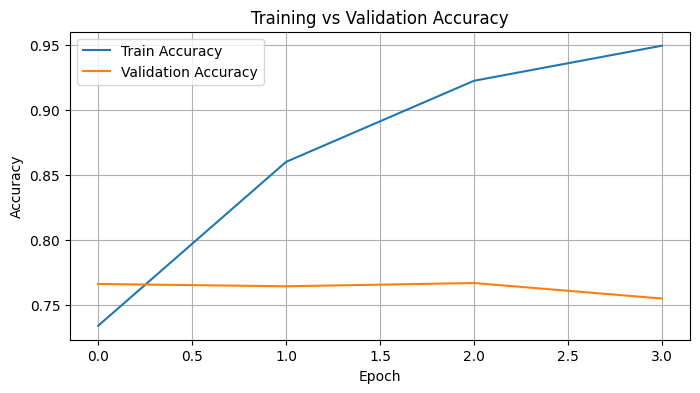

In [148]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# ==================================================
# 1. Predict on Test Set
# ==================================================

X_test_tensor = tf.constant(X_test_new.tolist(), dtype=tf.string)

y_pred_probs = new_model.predict(
    X_test_tensor,
    batch_size=64,
    verbose=0
).flatten()


# ==================================================
# 2. Find Optimal Threshold using F1
# ==================================================

thresholds = np.arange(0.1, 0.91, 0.01)

f1_scores = [
    f1_score(y_test_new, (y_pred_probs >= t).astype(int), zero_division=0)
    for t in thresholds
]

best_threshold = thresholds[np.argmax(f1_scores)]

y_pred = (y_pred_probs >= best_threshold).astype(int)


# ==================================================
# 3. Final Metrics
# ==================================================

accuracy = accuracy_score(y_test_new, y_pred)
precision = precision_score(y_test_new, y_pred, zero_division=0)
recall = recall_score(y_test_new, y_pred, zero_division=0)
f1 = f1_score(y_test_new, y_pred, zero_division=0)
auc = roc_auc_score(y_test_new, y_pred_probs)

print("=" * 50)
print("FINAL RESULTS")
print("=" * 50)

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"AUC Score      : {auc:.4f}")


# ==================================================
# 4. Classification Report + Accuracy لكل Class
# ==================================================

print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_test_new,
    y_pred,
    target_names=["Negative", "Positive"],
    zero_division=0
))

for i, name in enumerate(["Negative", "Positive"]):
    class_acc = np.mean(y_pred[y_test_new == i] == i)
    print(f"{name} Accuracy: {class_acc:.4f}")


# ==================================================
# 5. Training & Validation Accuracy Graph
# ==================================================

plt.figure(figsize=(8, 4))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [214]:
!pip install -q openai-whisper

In [215]:
import whisper

speech_model = whisper.load_model("small")

In [216]:
def predict_text(text):

    input_tensor = tf.constant([str(text)], dtype=tf.string)

    positive_probability = float(
        new_model.predict(input_tensor, verbose=0)[0][0]
    )

    negative_probability = 1 - positive_probability

    # Choose class with higher probability
    if positive_probability >= negative_probability:
        prediction = "Positive"
    else:
        prediction = "Negative"

    print("=" * 50)
    print("Input Text:")
    print(text)
    print("-" * 50)
    print(f"Positive Probability: {positive_probability * 100:.2f}%")
    print(f"Negative Probability: {negative_probability * 100:.2f}%")
    print(f"Prediction: {prediction}")
    print("=" * 50)

    return prediction

In [217]:
thresholds = np.arange(0.30, 0.71, 0.01)

f1_scores = []

for t in thresholds:
    temp_pred = (y_pred_probs >= t).astype(int)
    score = f1_score(y_test_new, temp_pred, zero_division=0)
    f1_scores.append(score)

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)
print("Best F1:", max(f1_scores))

Best Threshold: 0.4400000000000001
Best F1: 0.7793479781726599


In [218]:
print(df[["label", "label_encoded"]].drop_duplicates())

  label  label_encoded
0   neg            0.0
2   pos            1.0


In [219]:
predict_audio(
    "/kaggle/input/datasets/habibamuhammed1/negative/WhatsApp Video 2026-09-03 at 1.47.38 AM.mp4"
)

Transcribing audio...

Extracted Text:
 أولئ المجرمون البلا قلب البلا رحمة الذين لا يفكرون أبدا بالفقراء والمساكين البشعون السامون قمامة القمامة الوحوشة المدوح جون المقرفون الخينون أطاينون في الظهر أصحاب الضماء الميتى

Classification Result:
Input Text:
 أولئ المجرمون البلا قلب البلا رحمة الذين لا يفكرون أبدا بالفقراء والمساكين البشعون السامون قمامة القمامة الوحوشة المدوح جون المقرفون الخينون أطاينون في الظهر أصحاب الضماء الميتى
--------------------------------------------------
Positive Probability: 47.04%
Negative Probability: 52.96%
Prediction: Negative


' أولئ المجرمون البلا قلب البلا رحمة الذين لا يفكرون أبدا بالفقراء والمساكين البشعون السامون قمامة القمامة الوحوشة المدوح جون المقرفون الخينون أطاينون في الظهر أصحاب الضماء الميتى'

In [223]:
predict_audio(
    "/kaggle/input/datasets/habibamuhammed1/pos-video/WhatsApp Video 2026-09-03 at 7.55.55 AM.mp4"
)

Transcribing audio...

Extracted Text:
 أهلاً يقولون وجود الناس اللطيفة في حياتك نعمة وجود الناس المرحين والرائعين سعادة وجودك عزيز المستمع يطفي للحياة جانبا سعيدة

Classification Result:
Input Text:
 أهلاً يقولون وجود الناس اللطيفة في حياتك نعمة وجود الناس المرحين والرائعين سعادة وجودك عزيز المستمع يطفي للحياة جانبا سعيدة
--------------------------------------------------
Positive Probability: 81.88%
Negative Probability: 18.12%
Prediction: Positive


' أهلاً يقولون وجود الناس اللطيفة في حياتك نعمة وجود الناس المرحين والرائعين سعادة وجودك عزيز المستمع يطفي للحياة جانبا سعيدة'

In [224]:
test_samples = [
    "أنا سعيد جدا وأحب الحياة",
    "هذا يوم جميل وأنا أشعر بالسعادة",
    "أنا حزين جدا وأشعر بالغضب",
    "هذا شيء سيء جدا وأنا أكرهه"
]

for text in test_samples:
    print("\nTEXT:", text)
    predict_text(text)


TEXT: أنا سعيد جدا وأحب الحياة
Input Text:
أنا سعيد جدا وأحب الحياة
--------------------------------------------------
Positive Probability: 65.77%
Negative Probability: 34.23%
Prediction: Positive

TEXT: هذا يوم جميل وأنا أشعر بالسعادة
Input Text:
هذا يوم جميل وأنا أشعر بالسعادة
--------------------------------------------------
Positive Probability: 73.38%
Negative Probability: 26.62%
Prediction: Positive

TEXT: أنا حزين جدا وأشعر بالغضب
Input Text:
أنا حزين جدا وأشعر بالغضب
--------------------------------------------------
Positive Probability: 28.99%
Negative Probability: 71.01%
Prediction: Negative

TEXT: هذا شيء سيء جدا وأنا أكرهه
Input Text:
هذا شيء سيء جدا وأنا أكرهه
--------------------------------------------------
Positive Probability: 38.89%
Negative Probability: 61.11%
Prediction: Negative


In [236]:
def analyze_video(video_path, video_name):

    # Speech to Text
    result = speech_model.transcribe(
        video_path,
        language="ar"
    )

    extracted_text = result["text"].strip()

    # Model Prediction
    input_tensor = tf.constant(
        [extracted_text],
        dtype=tf.string
    )

    positive_probability = float(
        new_model.predict(
            input_tensor,
            verbose=0
        )[0][0]
    )

    negative_probability = 1 - positive_probability

    # Final class based on highest probability
    if positive_probability >= 0.5:
        prediction = "Positive"
    else:
        prediction = "Negative"

    confidence = max(
        positive_probability,
        negative_probability
    ) * 100

    return {
        "Video": video_name,
        "Extracted Text": extracted_text,
        "Positive Probability": positive_probability * 100,
        "Negative Probability": negative_probability * 100,
        "Prediction": prediction,
        "Confidence": confidence
    }

In [237]:
video1 = analyze_video(
    "/kaggle/input/datasets/habibamuhammed1/negative/WhatsApp Video 2026-09-03 at 1.47.38 AM.mp4",
    "Negative Video"
)

In [238]:
video2 = analyze_video(
    "/kaggle/input/datasets/habibamuhammed1/pos-video/WhatsApp Video 2026-09-03 at 7.55.55 AM.mp4",
    "Positive Video"
)

In [239]:
comparison = pd.DataFrame([video1, video2])

comparison

,Video,Extracted Text,Positive Probability,Negative Probability,Prediction,Confidence
0,Negative Video,أولئ المجرمون البلا قلب البلا رحمة الذين لا يف...,47.039670,52.960330,Negative,52.960330
1,Positive Video,أهلاً يقولون وجود الناس اللطيفة في حياتك نعمة ...,81.879997,18.120003,Positive,81.879997
